# 07. Applying Visualization Best Practices for Data Storytelling

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply visualization best practices
- Tell stories with data
- Choose appropriate charts
- Design effective visualizations
- Communicate insights clearly

## 🔗 Prerequisites

- ✅ Understanding of data visualization
- ✅ Understanding of storytelling
- ✅ Design principles knowledge

---

This notebook covers practical activities from **Course 05, Unit 3**:
- Applying visualization best practices for data storytelling

---

## Introduction

**Visualization best practices** ensure charts effectively communicate insights and tell compelling data stories that engage and inform audiences.

## The Story

**BEFORE**: You can create visualizations but don't know design principles for effective communication.

**AFTER**: You'll learn visualization best practices: color theory, accessibility, storytelling, and avoiding common mistakes!

**Why this matters**: Applying Visualization Best Practices for Data Storytelling is essential for building complete, professional data science solutions!

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Data
- matplotlib, seaborn

**Outputs:** What you'll see when you run the cells

- Best-practice examples
- Do's and don'ts

---

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
print("✅ Libraries imported!")
print("\nVisualization Best Practices - shown, not just listed")
print("=" * 60)
print("""
Principles we will DEMONSTRATE below (each with a don't/do chart pair):
  1. Choose the right chart type (and avoid clutter)
  2. Use honest axis scales
  3. Highlight the story - guide the reader's eye
""")

✅ Libraries imported!

Visualization Best Practices - shown, not just listed

Principles we will DEMONSTRATE below (each with a don't/do chart pair):
  1. Choose the right chart type (and avoid clutter)
  2. Use honest axis scales
  3. Highlight the story - guide the reader's eye



## Practice 1: Right Chart Type, Less Clutter

**Don't** cram many categories into a pie chart — slices become unreadable and
comparisons impossible. **Do** use a sorted horizontal bar chart.

Practice 1: pie chart with many slices vs sorted bar chart
------------------------------------------------------------


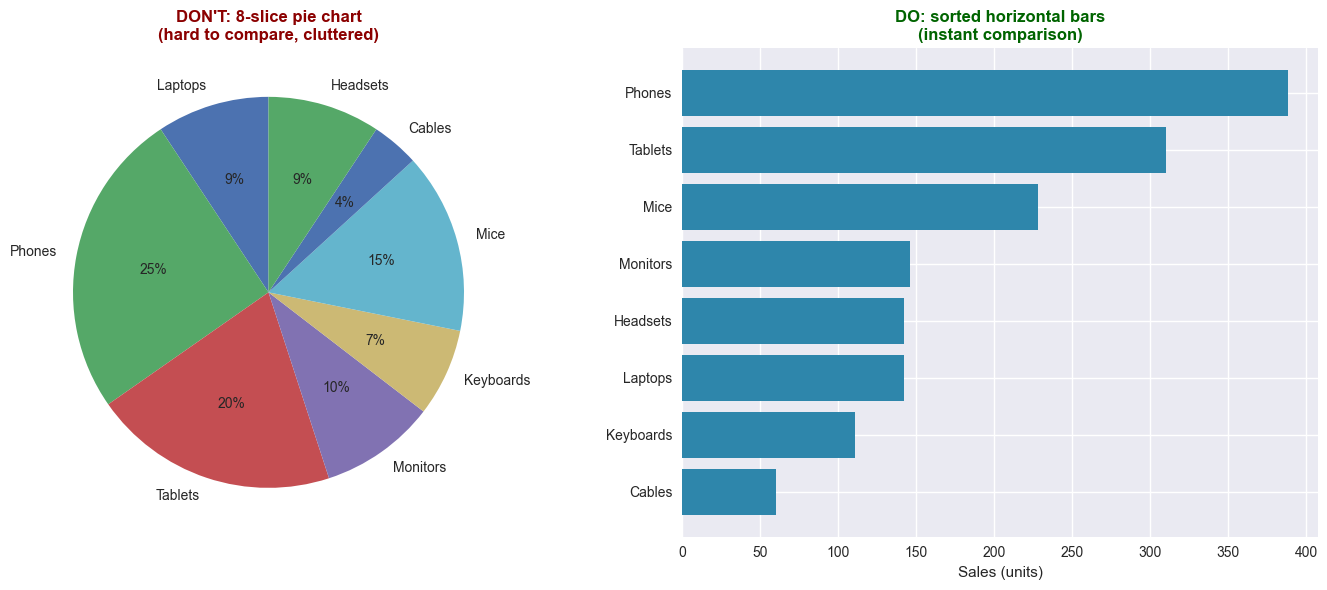

💡 Rule: many categories → sorted bars, not pie slices


In [2]:
print("Practice 1: pie chart with many slices vs sorted bar chart")
print("-" * 60)

np.random.seed(42)
products = ['Laptops', 'Phones', 'Tablets', 'Monitors', 'Keyboards',
            'Mice', 'Cables', 'Headsets']
sales = np.random.randint(40, 400, len(products))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(sales, labels=products, autopct='%1.0f%%', startangle=90)
axes[0].set_title("DON'T: 8-slice pie chart\n(hard to compare, cluttered)",
                  color='darkred', fontweight='bold')

order = np.argsort(sales)
axes[1].barh(np.array(products)[order], sales[order], color='#2E86AB')
axes[1].set_xlabel('Sales (units)')
axes[1].set_title('DO: sorted horizontal bars\n(instant comparison)',
                  color='darkgreen', fontweight='bold')
plt.tight_layout()
plt.show()
print("💡 Rule: many categories → sorted bars, not pie slices")

## Practice 2: Honest Axis Scales

**Don't** truncate the y-axis to exaggerate small differences.
**Do** start bars at zero (or clearly flag any zoomed axis).

Practice 2: truncated vs zero-based axis
------------------------------------------------------------


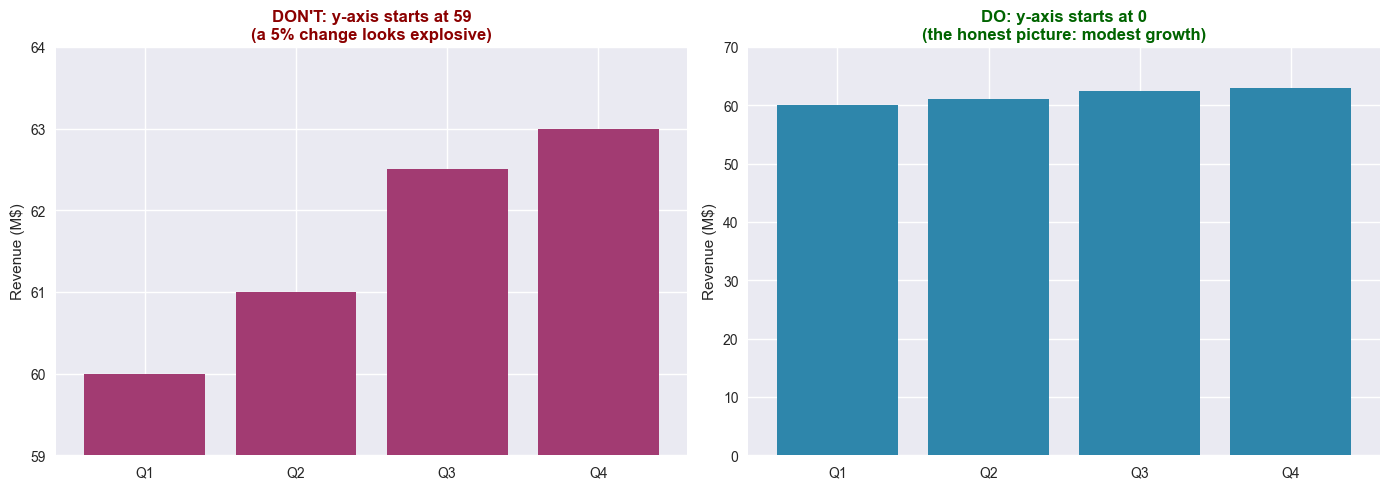

💡 The data grew 5.0% across the year - the left chart makes it
   look like a boom. Same numbers, different axis, different story.


In [3]:
print("Practice 2: truncated vs zero-based axis")
print("-" * 60)

quarters = ['Q1', 'Q2', 'Q3', 'Q4']
revenue = [60, 61, 62.5, 63]  # nearly flat in reality

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(quarters, revenue, color='#A23B72')
axes[0].set_ylim(59, 64)  # the trick: axis starts at 59
axes[0].set_title("DON'T: y-axis starts at 59\n(a 5% change looks explosive)",
                  color='darkred', fontweight='bold')
axes[0].set_ylabel('Revenue (M$)')

axes[1].bar(quarters, revenue, color='#2E86AB')
axes[1].set_ylim(0, 70)
axes[1].set_title('DO: y-axis starts at 0\n(the honest picture: modest growth)',
                  color='darkgreen', fontweight='bold')
axes[1].set_ylabel('Revenue (M$)')
plt.tight_layout()
plt.show()

growth = (revenue[-1] - revenue[0]) / revenue[0]
print(f"💡 The data grew {growth:.1%} across the year - the left chart makes it")
print("   look like a boom. Same numbers, different axis, different story.")

## Practice 3: Highlight the Story

**Don't** give every series equal visual weight.
**Do** push context into the background and highlight the one line that
carries the story — that is data storytelling in a single move.

Practice 3: equal-weight spaghetti vs highlighted story
------------------------------------------------------------


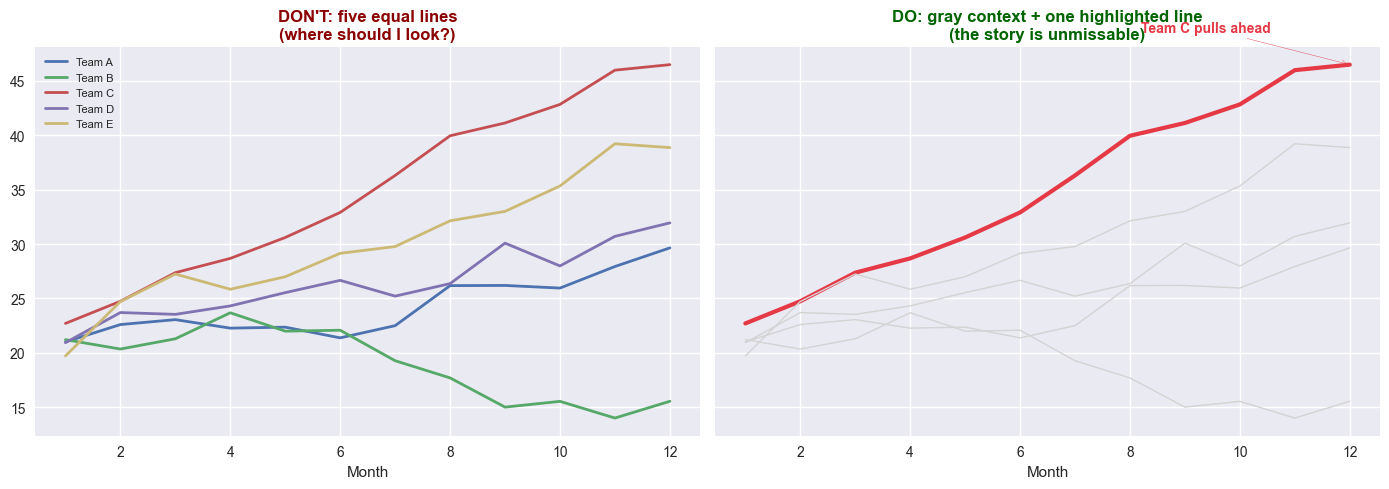

💡 Storytelling = contrast: mute the context, color the message


In [4]:
print("Practice 3: equal-weight spaghetti vs highlighted story")
print("-" * 60)

rng = np.random.default_rng(7)
months = np.arange(1, 13)
teams = {f'Team {ch}': np.cumsum(rng.normal(1, 2, 12)) + 20 for ch in 'ABCDE'}
star = 'Team C'
teams[star] = np.cumsum(rng.normal(2.5, 1, 12)) + 20  # the story: C pulls ahead

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for name, vals in teams.items():
    axes[0].plot(months, vals, linewidth=2, label=name)
axes[0].legend(fontsize=8)
axes[0].set_title("DON'T: five equal lines\n(where should I look?)",
                  color='darkred', fontweight='bold')
axes[0].set_xlabel('Month')

for name, vals in teams.items():
    if name == star:
        axes[1].plot(months, vals, linewidth=3, color='#E63946', label=star)
    else:
        axes[1].plot(months, vals, linewidth=1, color='lightgray')
axes[1].annotate(f'{star} pulls ahead', xy=(12, teams[star][-1]),
                 xytext=(8.2, teams[star][-1] + 3),
                 arrowprops=dict(arrowstyle='->', color='#E63946'),
                 color='#E63946', fontweight='bold')
axes[1].set_title('DO: gray context + one highlighted line\n(the story is unmissable)',
                  color='darkgreen', fontweight='bold')
axes[1].set_xlabel('Month')
plt.tight_layout()
plt.show()
print("💡 Storytelling = contrast: mute the context, color the message")

In [5]:
print("=" * 60)
print("Summary")
print("=" * 60)
print("""
✅ Best practices you just SAW applied (three don't/do chart pairs):
   1. Right chart type: sorted bars beat a crowded pie
   2. Honest scales: zero-based axes tell the true story
   3. Storytelling: mute the context, highlight the message

🎯 Checklist for every chart you make:
   - Does the chart type match the question?
   - Are the axes honest and labeled?
   - Is there one clear message, highlighted?
   - Could anything be removed without losing meaning?

📚 Next Steps:
   - Example 08: Advanced Visualization Types (violin, heatmap, pairs, facets)
""")
print("✅ Visualization best practices - demonstrated!")

Summary

✅ Best practices you just SAW applied (three don't/do chart pairs):
   1. Right chart type: sorted bars beat a crowded pie
   2. Honest scales: zero-based axes tell the true story
   3. Storytelling: mute the context, highlight the message

🎯 Checklist for every chart you make:
   - Does the chart type match the question?
   - Are the axes honest and labeled?
   - Is there one clear message, highlighted?
   - Could anything be removed without losing meaning?

📚 Next Steps:
   - Example 08: Advanced Visualization Types (violin, heatmap, pairs, facets)

✅ Visualization best practices - demonstrated!
